In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys, os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from NNMFit.utilities import ScanHandler

# import plotting utils
sys.path.append( "/data/user/tvaneede/utils" )
from FlavourScansPlotting import get_contour_points, get_contour_points_angle

# import scanning points
from flavor_fracs import *
points = pd.read_pickle('/data/user/tvaneede/GlobalFit/custom_scan_flavor/default_custom_scan_points_flavor.pickle')
flavs = flavor_frac(np.asarray(points['astro_nue_ratio']),np.asarray(points['astro_nutau_ratio']))

# import plotting flavor triangle
sys.path.append( "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks" )
from plot_utils_triangle import *


In [10]:
plotting_path = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/unblind/step2_hese_flavor/flavor_triangle"
os.system(f"mkdir -p {plotting_path}")

0

In [4]:
dag_path = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese/unblind/step2_hese_flavor/"
scan_dir_dict = {
    "nbestfit50_fine_0" : f"{dag_path}/data_fits_flavor_triangle/nbestfit50_fine_0",
    "nbestfit50_fine_1" : f"{dag_path}/data_fits_flavor_triangle/nbestfit50_fine_1",
    "nbestfit50_fine_2" : f"{dag_path}/data_fits_flavor_triangle/nbestfit50_fine_2",
}

In [5]:
N_grid = 40 # 20 was standard
drop_unsuccessful = False
scan_dict = {}
data = {}
bestfits = {}
for name, scan_dir in scan_dir_dict.items():
    print(name)
    data[name] = {}
    scan_dict[name] = ScanHandler(scan_dir,dump=False,drop_unsuccessful=drop_unsuccessful)
    data[name]["ftau"],data[name]["fe"],data[name]["ts"],data[name]["ftau_grid"],data[name]["fe_grid"],data[name]["ts_grid"] = get_contour_points(scan_dict,name, N_grid=N_grid)
    bestfits[name] = scan_dict[name].get_freefit()

nbestfit50_fine_0
removed stuff
nbestfit50_fine_1
removed stuff
nbestfit50_fine_2
removed stuff


In [6]:
# Combine scans: take lowest dllh at each scan point, renormalized to global best fit
# dllh convention: 2*(scan_llh - freefit_llh), renormalize by 2*(freefit_llh_s - global_best_llh)
# Scans may have different numbers of points (dropped unsuccessful fits), so merge by coordinates

global_best_name = min(bestfits, key=lambda n: bestfits[n]["llh"])
global_best_llh = bestfits[global_best_name]["llh"]

dfs = []
for name in scan_dir_dict:
    shift = 2 * (bestfits[name]["llh"] - global_best_llh)
    dfs.append(pd.DataFrame({
        "ftau": data[name]["ftau"],
        "fe":   data[name]["fe"],
        "ts":   data[name]["ts"] + shift,
    }))

combined_df = pd.concat(dfs).groupby(["ftau", "fe"], as_index=False)["ts"].min()
combined_ftau = combined_df["ftau"].values
combined_fe   = combined_df["fe"].values
combined_ts   = combined_df["ts"].values

from FlavourScansPlotting import grided_TS_nutau_nue
ftau_grid, fe_grid, ts_grid = grided_TS_nutau_nue(
    combined_ftau, combined_fe, combined_ts, interp_method='linear', N_grid=N_grid
)

data["combined"] = {
    "ftau":      combined_ftau,
    "fe":        combined_fe,
    "ts":        combined_ts,
    "ftau_grid": ftau_grid,
    "fe_grid":   fe_grid,
    "ts_grid":   ts_grid,
}
bestfits["combined"] = bestfits[global_best_name]

print(f"Global best fit from: {global_best_name} (llh={global_best_llh:.4f})")
print(f"Combined scan points: {len(combined_ts)}")

removed stuff
Global best fit from: nbestfit50_fine_1 (llh=188.1160)
Combined scan points: 268


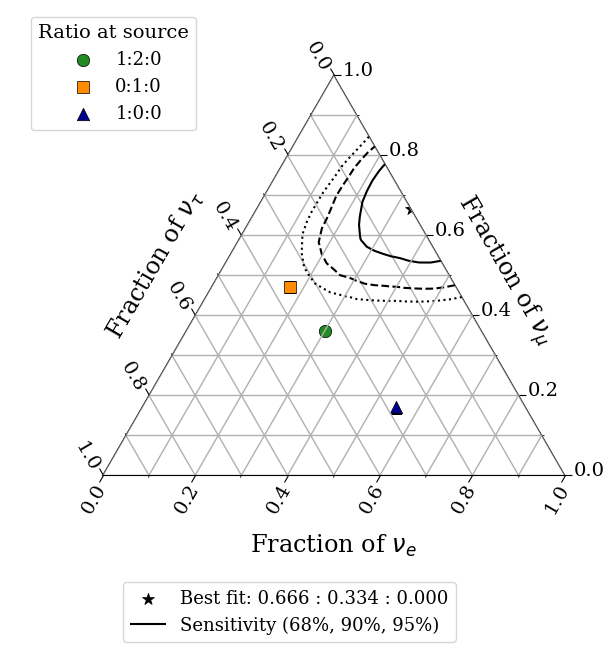

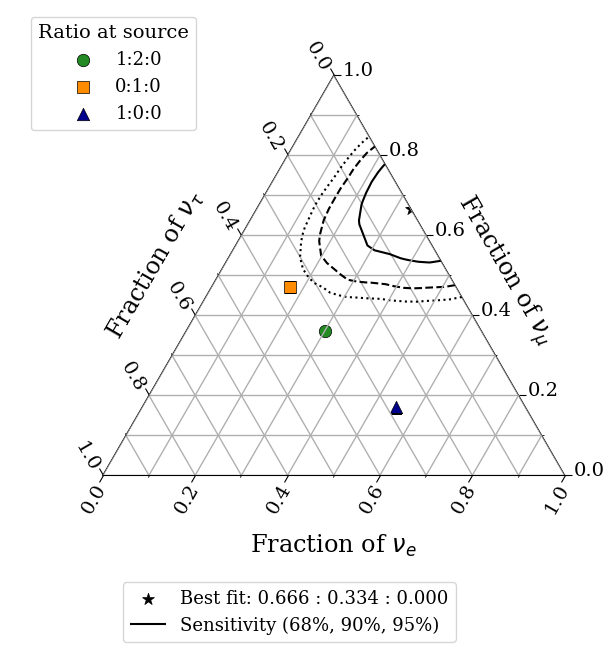

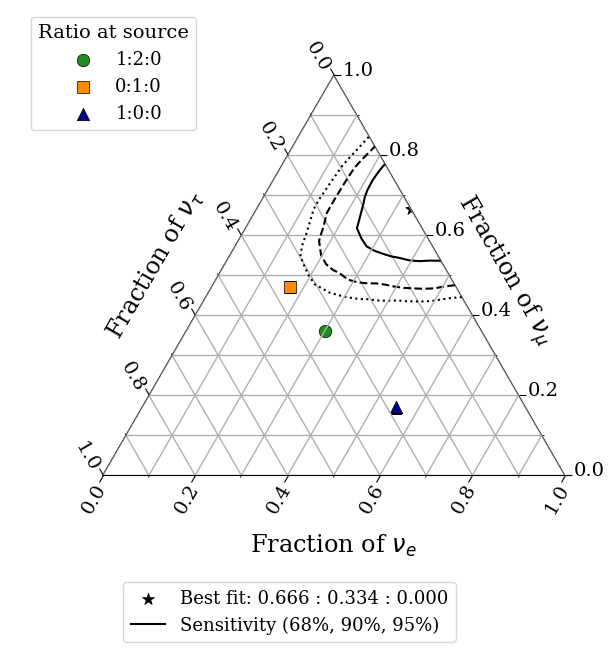

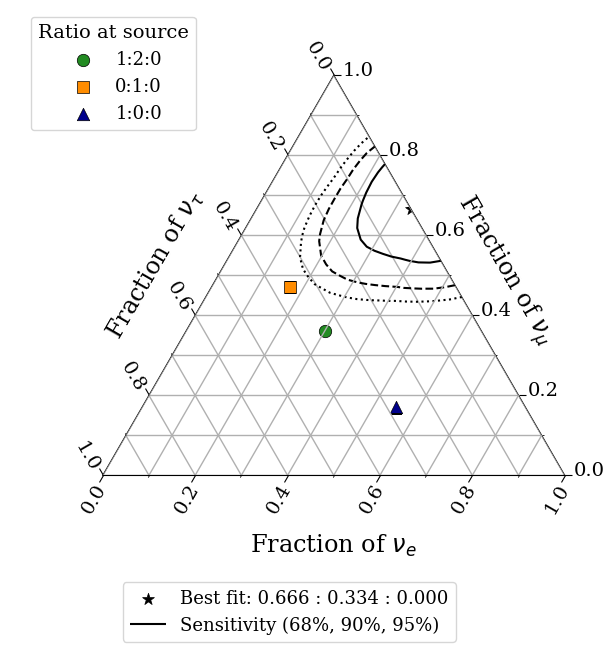

In [ ]:
for name in data:

    f_e = bestfits[name]["astro_nue_ratio"] / (1 + bestfits[name]["astro_nue_ratio"] + bestfits[name]["astro_nutau_ratio"])
    f_mu = 1 / (1 + bestfits[name]["astro_nue_ratio"] + bestfits[name]["astro_nutau_ratio"])
    f_tau = bestfits[name]["astro_nutau_ratio"] / (1 + bestfits[name]["astro_nue_ratio"] + bestfits[name]["astro_nutau_ratio"])

    C = plot_contour( data = data,
                    name = name,
                    label = "Sensitivity",
                    levels = ["68%","90%","95%"],
                    title = "",
                    scenarios=True,
                    show_ts_labels=False,
                    bestfit=[f_tau,f_e],
                    savepath = f"{plotting_path}/flavor_triangle_{name}.png")
